In [1]:
from io import StringIO
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [2]:
USGS_ALL_MONTH = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.csv"
EARTH_RADIUS_KM = 6371.0088



In [3]:
def download_raw_usgs(url=USGS_ALL_MONTH) -> pd.DataFrame:
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    return pd.read_csv(StringIO(r.text))

df_raw = download_raw_usgs()
print("RAW shape:", df_raw.shape)
df_raw.to_csv("raw_all_month.csv", index=False)
print("Saved raw_all_month.csv")
df_raw.head()

RAW shape: (9665, 22)
Saved raw_all_month.csv


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-02-24T19:04:55.330Z,38.757832,-122.748497,1.32,1.17,md,8,94,0.01864,0.02,...,2026-02-24T19:06:32.868Z,"2 km SSE of The Geysers, CA",earthquake,0.33,0.5400,0.080000,6.0,automatic,nc,nc
1,2026-02-24T19:04:23.042Z,55.554000,-158.295000,27.80,3.00,ml,17,250,0.70000,0.20,...,2026-02-24T19:06:23.896Z,"66 km SE of Perryville, Alaska",earthquake,11.70,5.0011,0.100000,4.0,automatic,ak,ak
2,2026-02-24T18:48:12.799Z,52.396000,-169.744000,14.30,2.40,ml,10,294,0.40000,0.30,...,2026-02-24T19:14:04.937Z,"84 km SW of Nikolski, Alaska",earthquake,10.70,3.7874,0.100000,7.0,reviewed,ak,ak
3,2026-02-24T18:47:15.880Z,38.836834,-122.793167,2.07,1.62,md,20,68,0.01431,0.03,...,2026-02-24T18:48:52.972Z,"6 km WNW of Cobb, CA",earthquake,0.24,0.4500,0.140000,21.0,automatic,nc,nc
4,2026-02-24T18:44:00.680Z,19.045334,-155.388000,31.75,2.15,md,34,213,0.13000,0.14,...,2026-02-24T18:47:56.330Z,"19 km SSE of Pāhala, Hawaii",earthquake,0.80,0.6500,0.136736,16.0,automatic,hv,hv


In [4]:
# --- Initial Data Inspection (USGS Earthquakes) ---

print("\n--- Initial Data (Head) ---")
display(df_raw.head())

# Columns used in this project (safe even if some columns are missing)
selected_cols = ["id", "time", "latitude", "longitude", "depth", "mag", "place", "type"]
selected_cols = [c for c in selected_cols if c in df_raw.columns]
df_selected = df_raw[selected_cols].copy()

print("\n--- Initial Data (Info for Selected Features) ---")
print(df_selected.info())

print("\n--- Initial Data (Missing Values for Selected Features) ---")
print(df_selected.isnull().sum())

print("\n--- Initial Data (Basic Shape) ---")
print("Rows, Columns:", df_raw.shape)
print("Selected Columns:", df_selected.shape)

# Extra inspection (recommended for report quality)
if "type" in df_selected.columns:
    print("\n--- Event Type Counts (Top 10) ---")
    print(df_selected["type"].value_counts().head(10))

if all(c in df_selected.columns for c in ["mag", "depth"]):
    print("\n--- Summary Stats (mag & depth) ---")
    print(df_selected[["mag", "depth"]].describe())


--- Initial Data (Head) ---


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-02-24T19:04:55.330Z,38.757832,-122.748497,1.32,1.17,md,8,94,0.01864,0.02,...,2026-02-24T19:06:32.868Z,"2 km SSE of The Geysers, CA",earthquake,0.33,0.5400,0.080000,6.0,automatic,nc,nc
1,2026-02-24T19:04:23.042Z,55.554000,-158.295000,27.80,3.00,ml,17,250,0.70000,0.20,...,2026-02-24T19:06:23.896Z,"66 km SE of Perryville, Alaska",earthquake,11.70,5.0011,0.100000,4.0,automatic,ak,ak
2,2026-02-24T18:48:12.799Z,52.396000,-169.744000,14.30,2.40,ml,10,294,0.40000,0.30,...,2026-02-24T19:14:04.937Z,"84 km SW of Nikolski, Alaska",earthquake,10.70,3.7874,0.100000,7.0,reviewed,ak,ak
3,2026-02-24T18:47:15.880Z,38.836834,-122.793167,2.07,1.62,md,20,68,0.01431,0.03,...,2026-02-24T18:48:52.972Z,"6 km WNW of Cobb, CA",earthquake,0.24,0.4500,0.140000,21.0,automatic,nc,nc
4,2026-02-24T18:44:00.680Z,19.045334,-155.388000,31.75,2.15,md,34,213,0.13000,0.14,...,2026-02-24T18:47:56.330Z,"19 km SSE of Pāhala, Hawaii",earthquake,0.80,0.6500,0.136736,16.0,automatic,hv,hv



--- Initial Data (Info for Selected Features) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9665 entries, 0 to 9664
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         9665 non-null   object 
 1   time       9665 non-null   object 
 2   latitude   9665 non-null   float64
 3   longitude  9665 non-null   float64
 4   depth      9665 non-null   float64
 5   mag        9664 non-null   float64
 6   place      9665 non-null   object 
 7   type       9665 non-null   object 
dtypes: float64(4), object(4)
memory usage: 604.2+ KB
None

--- Initial Data (Missing Values for Selected Features) ---
id           0
time         0
latitude     0
longitude    0
depth        0
mag          1
place        0
type         0
dtype: int64

--- Initial Data (Basic Shape) ---
Rows, Columns: (9665, 22)
Selected Columns: (9665, 8)

--- Event Type Counts (Top 10) ---
type
earthquake          9518
explosion             67
quarry bl

In [5]:
# --- Column Selection (keep only relevant fields) ---

keep_cols = ["id", "time", "latitude", "longitude", "depth", "mag", "place", "type"]
keep_cols = [c for c in keep_cols if c in df_raw.columns]  # safe if any column missing

df_cols = df_raw[keep_cols].copy()

print("\n--- Columns Retained ---")
print(keep_cols)

print("\n--- Shape After Column Selection ---")
print("Rows, Columns:", df_cols.shape)

print("\n--- Preview After Column Selection (Head) ---")
display(df_cols.head())


--- Columns Retained ---
['id', 'time', 'latitude', 'longitude', 'depth', 'mag', 'place', 'type']

--- Shape After Column Selection ---
Rows, Columns: (9665, 8)

--- Preview After Column Selection (Head) ---


,id,time,latitude,longitude,depth,mag,place,type
0,nc75318497,2026-02-24T19:04:55.330Z,38.757832,-122.748497,1.32,1.17,"2 km SSE of The Geysers, CA",earthquake
1,aka2026dwpdrj,2026-02-24T19:04:23.042Z,55.554000,-158.295000,27.80,3.00,"66 km SE of Perryville, Alaska",earthquake
2,aka2026dwopus,2026-02-24T18:48:12.799Z,52.396000,-169.744000,14.30,2.40,"84 km SW of Nikolski, Alaska",earthquake
3,nc75318477,2026-02-24T18:47:15.880Z,38.836834,-122.793167,2.07,1.62,"6 km WNW of Cobb, CA",earthquake
4,hv74907886,2026-02-24T18:44:00.680Z,19.045334,-155.388000,31.75,2.15,"19 km SSE of Pāhala, Hawaii",earthquake


In [6]:
# --- Handling Missing Coordinates (latitude/longitude) ---

before_rows = df_cols.shape[0]

missing_lat = df_cols["latitude"].isna().sum()
missing_lon = df_cols["longitude"].isna().sum()

print("--- Missing Values Before ---")
print("Missing latitude:", missing_lat)
print("Missing longitude:", missing_lon)
print("Rows before:", before_rows)

df_no_missing = df_cols.dropna(subset=["latitude", "longitude"]).copy()

after_rows = df_no_missing.shape[0]
print("\n--- After Dropping Missing Coordinates ---")
print("Rows after:", after_rows)
print("Removed rows:", before_rows - after_rows)

display(df_no_missing.head())

--- Missing Values Before ---
Missing latitude: 0
Missing longitude: 0
Rows before: 9665

--- After Dropping Missing Coordinates ---
Rows after: 9665
Removed rows: 0


,id,time,latitude,longitude,depth,mag,place,type
0,nc75318497,2026-02-24T19:04:55.330Z,38.757832,-122.748497,1.32,1.17,"2 km SSE of The Geysers, CA",earthquake
1,aka2026dwpdrj,2026-02-24T19:04:23.042Z,55.554000,-158.295000,27.80,3.00,"66 km SE of Perryville, Alaska",earthquake
2,aka2026dwopus,2026-02-24T18:48:12.799Z,52.396000,-169.744000,14.30,2.40,"84 km SW of Nikolski, Alaska",earthquake
3,nc75318477,2026-02-24T18:47:15.880Z,38.836834,-122.793167,2.07,1.62,"6 km WNW of Cobb, CA",earthquake
4,hv74907886,2026-02-24T18:44:00.680Z,19.045334,-155.388000,31.75,2.15,"19 km SSE of Pāhala, Hawaii",earthquake


In [7]:
# --- Coordinate Range Validation ---

before_rows = df_no_missing.shape[0]

invalid_mask = ~(
    df_no_missing["latitude"].between(-90, 90) &
    df_no_missing["longitude"].between(-180, 180)
)

invalid_count = int(invalid_mask.sum())
print("--- Invalid Coordinate Rows ---")
print("Invalid rows found:", invalid_count)

# Optional: show a few invalid rows (if any)
if invalid_count > 0:
    print("\nSample invalid rows:")
    display(df_no_missing.loc[invalid_mask, ["latitude", "longitude"]].head())

df_valid_coords = df_no_missing.loc[~invalid_mask].copy()

after_rows = df_valid_coords.shape[0]
print("\n--- After Range Validation ---")
print("Rows before:", before_rows)
print("Rows after:", after_rows)
print("Removed rows:", before_rows - after_rows)

display(df_valid_coords.head())

--- Invalid Coordinate Rows ---
Invalid rows found: 0

--- After Range Validation ---
Rows before: 9665
Rows after: 9665
Removed rows: 0


,id,time,latitude,longitude,depth,mag,place,type
0,nc75318497,2026-02-24T19:04:55.330Z,38.757832,-122.748497,1.32,1.17,"2 km SSE of The Geysers, CA",earthquake
1,aka2026dwpdrj,2026-02-24T19:04:23.042Z,55.554000,-158.295000,27.80,3.00,"66 km SE of Perryville, Alaska",earthquake
2,aka2026dwopus,2026-02-24T18:48:12.799Z,52.396000,-169.744000,14.30,2.40,"84 km SW of Nikolski, Alaska",earthquake
3,nc75318477,2026-02-24T18:47:15.880Z,38.836834,-122.793167,2.07,1.62,"6 km WNW of Cobb, CA",earthquake
4,hv74907886,2026-02-24T18:44:00.680Z,19.045334,-155.388000,31.75,2.15,"19 km SSE of Pāhala, Hawaii",earthquake


In [8]:
# --- Duplicate Removal (by unique earthquake id) ---

before_rows = df_valid_coords.shape[0]

# Count duplicates before removal
dup_count = int(df_valid_coords.duplicated(subset=["id"]).sum())
unique_ids_before = int(df_valid_coords["id"].nunique())

print("--- Duplicate Check (Before) ---")
print("Rows before:", before_rows)
print("Unique IDs before:", unique_ids_before)
print("Duplicate rows (by id):", dup_count)

# Remove duplicates
df_dedup = df_valid_coords.drop_duplicates(subset=["id"]).copy()

after_rows = df_dedup.shape[0]
unique_ids_after = int(df_dedup["id"].nunique())

print("\n--- After Removing Duplicates ---")
print("Rows after:", after_rows)
print("Unique IDs after:", unique_ids_after)
print("Removed rows:", before_rows - after_rows)

display(df_dedup.head())

--- Duplicate Check (Before) ---
Rows before: 9665
Unique IDs before: 9665
Duplicate rows (by id): 0

--- After Removing Duplicates ---
Rows after: 9665
Unique IDs after: 9665
Removed rows: 0


,id,time,latitude,longitude,depth,mag,place,type
0,nc75318497,2026-02-24T19:04:55.330Z,38.757832,-122.748497,1.32,1.17,"2 km SSE of The Geysers, CA",earthquake
1,aka2026dwpdrj,2026-02-24T19:04:23.042Z,55.554000,-158.295000,27.80,3.00,"66 km SE of Perryville, Alaska",earthquake
2,aka2026dwopus,2026-02-24T18:48:12.799Z,52.396000,-169.744000,14.30,2.40,"84 km SW of Nikolski, Alaska",earthquake
3,nc75318477,2026-02-24T18:47:15.880Z,38.836834,-122.793167,2.07,1.62,"6 km WNW of Cobb, CA",earthquake
4,hv74907886,2026-02-24T18:44:00.680Z,19.045334,-155.388000,31.75,2.15,"19 km SSE of Pāhala, Hawaii",earthquake


In [9]:
# --- Data Type Conversion (time -> datetime, mag/depth -> numeric) ---

print("--- Dtypes BEFORE conversion ---")
print(df_dedup[["time", "mag", "depth"]].dtypes)

df_types = df_dedup.copy()

# Convert data types safely
df_types["time"] = pd.to_datetime(df_types["time"], errors="coerce")
df_types["mag"] = pd.to_numeric(df_types["mag"], errors="coerce")
df_types["depth"] = pd.to_numeric(df_types["depth"], errors="coerce")

print("\n--- Dtypes AFTER conversion ---")
print(df_types[["time", "mag", "depth"]].dtypes)

print("\n--- Missing Values AFTER conversion ---")
print(df_types[["time", "mag", "depth"]].isna().sum())

display(df_types.head())

--- Dtypes BEFORE conversion ---
time      object
mag      float64
depth    float64
dtype: object

--- Dtypes AFTER conversion ---
time     datetime64[ns, UTC]
mag                  float64
depth                float64
dtype: object

--- Missing Values AFTER conversion ---
time     0
mag      1
depth    0
dtype: int64


,id,time,latitude,longitude,depth,mag,place,type
0,nc75318497,2026-02-24 19:04:55.330000+00:00,38.757832,-122.748497,1.32,1.17,"2 km SSE of The Geysers, CA",earthquake
1,aka2026dwpdrj,2026-02-24 19:04:23.042000+00:00,55.554000,-158.295000,27.80,3.00,"66 km SE of Perryville, Alaska",earthquake
2,aka2026dwopus,2026-02-24 18:48:12.799000+00:00,52.396000,-169.744000,14.30,2.40,"84 km SW of Nikolski, Alaska",earthquake
3,nc75318477,2026-02-24 18:47:15.880000+00:00,38.836834,-122.793167,2.07,1.62,"6 km WNW of Cobb, CA",earthquake
4,hv74907886,2026-02-24 18:44:00.680000+00:00,19.045334,-155.388000,31.75,2.15,"19 km SSE of Pāhala, Hawaii",earthquake


In [10]:
# --- Geospatial Preparation (degrees -> radians for Haversine distance) ---

# Make sure latitude/longitude are numeric first (safe check)
df_geo = df_types.copy()
df_geo["latitude"] = pd.to_numeric(df_geo["latitude"], errors="coerce")
df_geo["longitude"] = pd.to_numeric(df_geo["longitude"], errors="coerce")

# Drop any rows that became NaN after conversion (rare, but safe)
before_rows = df_geo.shape[0]
df_geo = df_geo.dropna(subset=["latitude", "longitude"]).copy()
after_rows = df_geo.shape[0]

print("--- Coordinate Numeric Check ---")
print("Rows before:", before_rows)
print("Rows after dropping NaN coords:", after_rows)
print("Removed rows:", before_rows - after_rows)

# Convert to radians (for Haversine DBSCAN)
coords_deg = df_geo[["latitude", "longitude"]].to_numpy(dtype=float)
coords_rad = np.radians(coords_deg)

print("\n--- Radians Conversion Output ---")
print("coords_rad shape:", coords_rad.shape)
print("First 5 rows (radians):")
print(coords_rad[:5])

# Keep df_geo for later use (labels will be added to this)
display(df_geo.head())

--- Coordinate Numeric Check ---
Rows before: 9665
Rows after dropping NaN coords: 9665
Removed rows: 0

--- Radians Conversion Output ---
coords_rad shape: (9665, 2)
First 5 rows (radians):
[[ 0.67645177 -2.14236542]
 [ 0.96960021 -2.76276894]
 [ 0.91448271 -2.96259169]
 [ 0.67783062 -2.14314507]
 [ 0.33240378 -2.71203223]]


,id,time,latitude,longitude,depth,mag,place,type
0,nc75318497,2026-02-24 19:04:55.330000+00:00,38.757832,-122.748497,1.32,1.17,"2 km SSE of The Geysers, CA",earthquake
1,aka2026dwpdrj,2026-02-24 19:04:23.042000+00:00,55.554000,-158.295000,27.80,3.00,"66 km SE of Perryville, Alaska",earthquake
2,aka2026dwopus,2026-02-24 18:48:12.799000+00:00,52.396000,-169.744000,14.30,2.40,"84 km SW of Nikolski, Alaska",earthquake
3,nc75318477,2026-02-24 18:47:15.880000+00:00,38.836834,-122.793167,2.07,1.62,"6 km WNW of Cobb, CA",earthquake
4,hv74907886,2026-02-24 18:44:00.680000+00:00,19.045334,-155.388000,31.75,2.15,"19 km SSE of Pāhala, Hawaii",earthquake


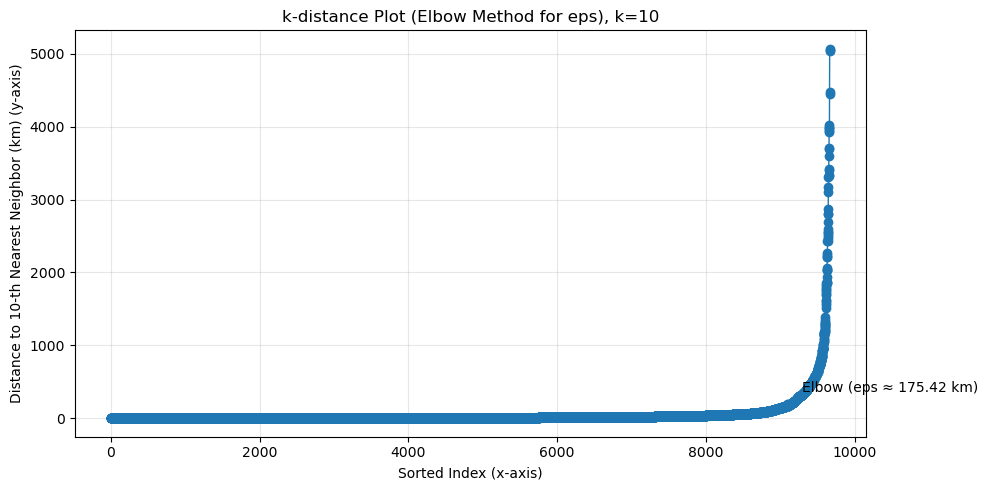

Suggested eps_km: 175.42210230031225


In [11]:
def estimate_elbow_index(sorted_vals: np.ndarray) -> int:
    x = np.arange(len(sorted_vals))
    y = sorted_vals
    x1, y1 = x[0], y[0]
    x2, y2 = x[-1], y[-1]
    num = np.abs((y2 - y1) * x - (x2 - x1) * y + (x2 * y1 - y2 * x1))
    den = np.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2)
    dist = num / den
    return int(np.argmax(dist))

def k_distance_plot_haversine(coords_rad: np.ndarray, k: int = 10, show_elbow: bool = True):
    nn = NearestNeighbors(n_neighbors=k, metric="haversine")
    nn.fit(coords_rad)
    distances, _ = nn.kneighbors(coords_rad)

    k_dist_rad = distances[:, k-1]
    k_dist_km = k_dist_rad * EARTH_RADIUS_KM
    k_sorted = np.sort(k_dist_km)

    elbow_idx = estimate_elbow_index(k_sorted)
    elbow_eps = k_sorted[elbow_idx]

    plt.figure(figsize=(10, 5))
    plt.plot(np.arange(len(k_sorted)), k_sorted, marker="o", linewidth=1)
    plt.xlabel("Sorted Index (x-axis)")
    plt.ylabel(f"Distance to {k}-th Nearest Neighbor (km) (y-axis)")
    plt.title(f"k-distance Plot (Elbow Method for eps), k={k}")

    if show_elbow:
        plt.scatter([elbow_idx], [elbow_eps], s=60)
        plt.annotate(f"Elbow (eps ≈ {elbow_eps:.2f} km)",
                     (elbow_idx, elbow_eps),
                     textcoords="offset points",
                     xytext=(10, 10))

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return elbow_eps, elbow_idx

min_samples = 10
suggested_eps_km, elbow_idx = k_distance_plot_haversine(coords_rad, k=min_samples, show_elbow=True)
print("Suggested eps_km:", suggested_eps_km)


In [16]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

# ---- 1) Safety check: coords_rad must exist ----
if "coords_rad" not in globals():
    raise NameError("coords_rad is not defined. Run your 'Geospatial Preparation (radians)' cell first.")

# ---- 2) Define run_dbscan_haversine() if missing ----
if "run_dbscan_haversine" not in globals():
    def run_dbscan_haversine(coords_rad: np.ndarray, eps_km: float, min_samples: int):
        """
        DBSCAN with haversine distance (coords must be in radians).
        Returns: labels, core_idx, model
        """
        eps_rad = float(eps_km) / 6371.0088  # km -> radians (Earth radius)
        model = DBSCAN(eps=eps_rad, min_samples=int(min_samples), metric="haversine")
        labels = model.fit_predict(coords_rad)
        core_idx = getattr(model, "core_sample_indices_", np.array([], dtype=int))
        return labels, core_idx, model

# ---- 3) Define metrics() if missing ----
if "metrics" not in globals():
    def metrics(coords_rad: np.ndarray, labels: np.ndarray):
        """
        Returns dict: clusters, noise_pct, silhouette, davies_bouldin
        Silhouette/DB are computed only on non-noise points and only if >= 2 clusters.
        """
        n = len(labels)
        noise = int((labels == -1).sum())
        clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = (noise / n) * 100 if n else 0.0

        # exclude noise
        mask = labels != -1
        coords_nn = coords_rad[mask]
        labels_nn = labels[mask]

        sil = None
        dbi = None
        if len(set(labels_nn.tolist())) >= 2:
            # using euclidean on radians coords (consistent with what you already used)
            sil = float(silhouette_score(coords_nn, labels_nn, metric="euclidean"))
            dbi = float(davies_bouldin_score(coords_nn, labels_nn))

        return {
            "clusters": clusters,
            "noise_pct": noise_pct,
            "silhouette": sil,
            "davies_bouldin": dbi
        }

print(" Functions are ready: run_dbscan_haversine(), metrics()")

 Functions are ready: run_dbscan_haversine(), metrics()


In [17]:
eps_km = 168.33
min_samples = 10

labels, core_idx, _ = run_dbscan_haversine(coords_rad, eps_km, min_samples)

m = metrics(coords_rad, labels)
print("eps_km:", eps_km, "min_samples:", min_samples)
print("clusters:", m["clusters"])
print("noise%:", m["noise_pct"])
print("silhouette:", m["silhouette"])
print("davies_bouldin:", m["davies_bouldin"])

eps_km: 168.33 min_samples: 10
clusters: 24
noise%: 5.142265907915157
silhouette: 0.48529269454454527
davies_bouldin: 1.3187134201099158


In [18]:
# --- Parameter Sweep Output Table ---

eps_list = [80, 100, 120, 140, 160, 168.33, 180, 200]     # you can adjust
min_samples_list = [5, 8, 10, 12, 15]

rows = []
for ms in min_samples_list:
    for eps in eps_list:
        labels, core_idx, _ = run_dbscan_haversine(coords_rad, eps, ms)
        m = metrics(coords_rad, labels)
        rows.append({
            "eps_km": eps,
            "min_samples": ms,
            "clusters": m["clusters"],
            "noise_pct": m["noise_pct"],
            "silhouette": m["silhouette"],
            "davies_bouldin": m["davies_bouldin"]
        })

sweep_df = pd.DataFrame(rows)
sweep_df

,eps_km,min_samples,clusters,noise_pct,silhouette,davies_bouldin
0,80.00,5,43,6.001035,0.267028,2.938671
1,100.00,5,41,5.225039,0.270040,2.652906
2,120.00,5,38,4.718055,0.210352,1.484174
3,140.00,5,39,4.314537,0.163983,1.474619
4,160.00,5,38,3.745473,0.480323,1.352112
5,168.33,5,40,3.579928,0.479884,1.558136
6,180.00,5,40,3.393689,0.496433,1.559044
7,200.00,5,40,3.031557,0.487876,1.846735
8,80.00,8,31,7.263321,0.280303,2.815528
9,100.00,8,29,6.321780,0.269381,2.503077


In [19]:
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score

def metrics(coords_rad, labels):
    """
    coords_rad: numpy array (N,2) in radians
    labels: cluster labels from DBSCAN (-1 = noise)
    Returns: dict with clusters, noise_pct, silhouette, davies_bouldin
    """
    labels = np.asarray(labels)
    n = labels.size

    # clusters excluding noise
    clusters = len(set(labels)) - (1 if -1 in set(labels) else 0)
    noise_pct = (labels == -1).sum() * 100.0 / n

    # compute metrics only on non-noise points
    mask = labels != -1
    X = coords_rad[mask]
    y = labels[mask]

    sil = None
    dbi = None
    # need at least 2 clusters to compute these
    if len(set(y)) >= 2 and len(y) >= 2:
        sil = float(silhouette_score(X, y))
        dbi = float(davies_bouldin_score(X, y))

    return {
        "clusters": clusters,
        "noise_pct": float(noise_pct),
        "silhouette": sil,
        "davies_bouldin": dbi
        
    }

    

In [20]:
# --- Top 10 Ranked Results ---

rank_df = sweep_df.copy()

# Remove rows where silhouette/davies is None (happens when <2 clusters)
rank_df = rank_df.dropna(subset=["silhouette", "davies_bouldin"])

# Sort: best silhouette (high), then best DB (low), then noise (low)
top10 = rank_df.sort_values(
    by=["silhouette", "davies_bouldin", "noise_pct"],
    ascending=[False, True, True]
).head(10)

top10

,eps_km,min_samples,clusters,noise_pct,silhouette,davies_bouldin
39,200.00,15,16,5.887222,0.691602,1.385607
31,200.00,12,20,5.193999,0.685373,2.917833
36,160.00,15,18,6.694258,0.617291,0.275478
37,168.33,15,18,6.508019,0.617205,0.288669
29,168.33,12,22,5.763063,0.615210,1.369761
38,180.00,15,17,6.280393,0.614642,0.289518
28,160.00,12,23,5.866529,0.614280,1.368708
30,180.00,12,20,5.628557,0.611593,1.473047
27,140.00,12,22,6.456286,0.554720,1.980211
25,100.00,12,18,7.904811,0.554219,2.136450


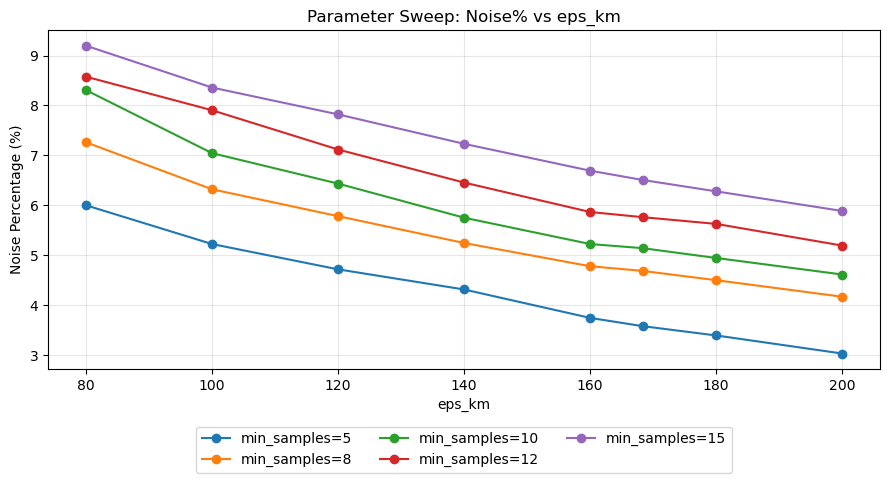

In [21]:
# --- Plot: Noise% vs eps (for each min_samples) ---

plt.figure(figsize=(9,5))

for ms in min_samples_list:
    subset = sweep_df[sweep_df["min_samples"] == ms].sort_values("eps_km")
    plt.plot(subset["eps_km"], subset["noise_pct"], marker="o", label=f"min_samples={ms}")

plt.title("Parameter Sweep: Noise% vs eps_km")
plt.xlabel("eps_km")
plt.ylabel("Noise Percentage (%)")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True)
plt.tight_layout()
plt.show()

In [22]:
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score

def compute_dbscan_metrics(coords_rad, labels):
    labels = np.asarray(labels)
    n = len(labels)

    # Number of clusters (exclude noise label -1)
    num_clusters = len(set(labels)) - (1 if -1 in set(labels) else 0)

    # Noise percentage
    noise_pct = (labels == -1).sum() * 100.0 / n

    # Compute silhouette & DB index on non-noise points only
    mask = labels != -1
    X = coords_rad[mask]
    y = labels[mask]

    sil = None
    dbi = None
    if len(set(y)) >= 2 and len(y) >= 2:
        sil = float(silhouette_score(X, y))
        dbi = float(davies_bouldin_score(X, y))

    return {
        "clusters": num_clusters,
        "noise_pct": float(noise_pct),
        "silhouette": sil,
        "davies_bouldin": dbi
    }

# Example: use your final model outputs
m = compute_dbscan_metrics(coords_rad, labels)

print("--- DBSCAN Metrics (Internal Evaluation) ---")
print("Number of clusters:", m["clusters"])
print("Noise percentage (%):", m["noise_pct"])
print("Silhouette score (excluding noise):", m["silhouette"])
print("Davies–Bouldin index (excluding noise):", m["davies_bouldin"])

--- DBSCAN Metrics (Internal Evaluation) ---
Number of clusters: 16
Noise percentage (%): 5.887221934816347
Silhouette score (excluding noise): 0.6916024815099954
Davies–Bouldin index (excluding noise): 1.3856067739515834


In [23]:
import pandas as pd

results_table = pd.DataFrame([{
    "eps_km": 168.33,
    "min_samples": 10,
    "clusters": m["clusters"],
    "noise%": m["noise_pct"],
    "silhouette": m["silhouette"],
    "davies_bouldin": m["davies_bouldin"]
}])

results_table

,eps_km,min_samples,clusters,noise%,silhouette,davies_bouldin
0,168.33,10,16,5.887222,0.691602,1.385607


In [24]:
import pandas as pd

# Put your final chosen parameters here
eps_km = 168.33
min_samples = 10

# If you already computed m = compute_dbscan_metrics(coords_rad, labels)
# then this will work. Otherwise, compute m first using the earlier metrics code.

metrics_matrix = pd.DataFrame(
    {
        "Value": [
            eps_km,
            min_samples,
            m["clusters"],
            round(m["noise_pct"], 3),
            None if m["silhouette"] is None else round(m["silhouette"], 3),
            None if m["davies_bouldin"] is None else round(m["davies_bouldin"], 3),
        ]
    },
    index=[
        "eps_km",
        "min_samples",
        "Number of clusters",
        "Noise percentage (%)",
        "Silhouette score (non-noise)",
        "Davies–Bouldin index (non-noise)",
    ],
)

metrics_matrix

,Value
eps_km,168.330
min_samples,10.000
Number of clusters,16.000
Noise percentage (%),5.887
Silhouette score (non-noise),0.692
Davies–Bouldin index (non-noise),1.386


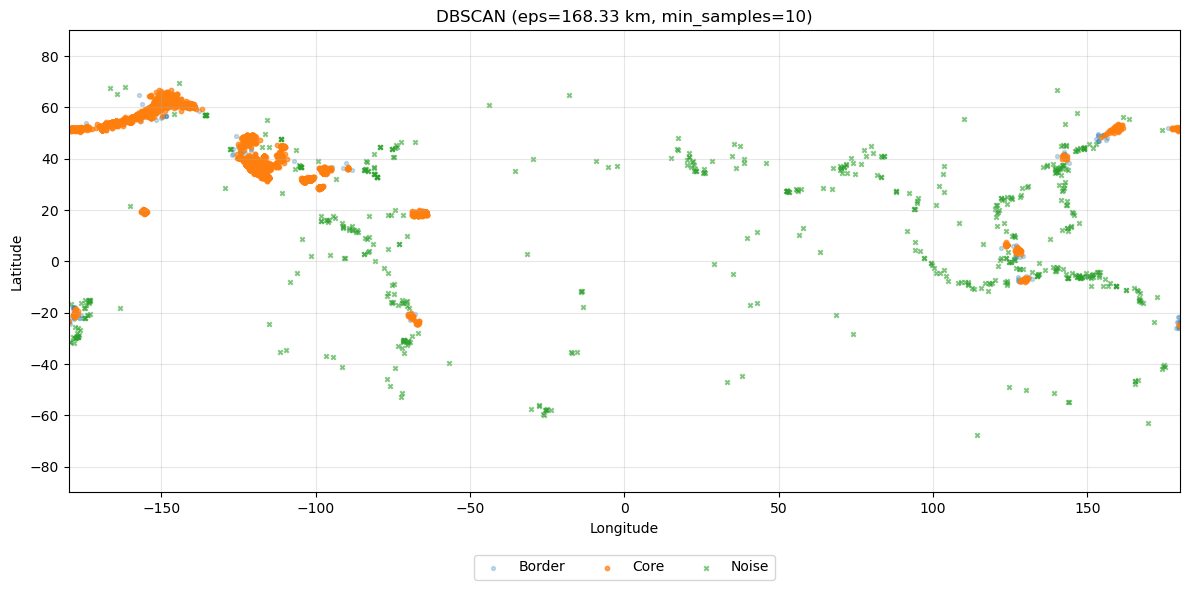

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_core_border_noise(df: pd.DataFrame, core_idx: np.ndarray, title: str = ""):
    n = len(df)
    is_core = np.zeros(n, dtype=bool)
    is_core[core_idx] = True

    if "cluster" not in df.columns:
        raise ValueError("df must contain a 'cluster' column. Add df['cluster']=labels first.")

    is_noise = df["cluster"].to_numpy() == -1
    is_border = (~is_noise) & (~is_core)

    plt.figure(figsize=(12, 6))

    plt.scatter(df.loc[is_border, "longitude"], df.loc[is_border, "latitude"],
                s=8, alpha=0.25, label="Border")

    plt.scatter(df.loc[is_core, "longitude"], df.loc[is_core, "latitude"],
                s=10, alpha=0.7, label="Core")

    plt.scatter(df.loc[is_noise, "longitude"], df.loc[is_noise, "latitude"],
                s=10, marker="x", alpha=0.6, label="Noise")

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(title if title else "DBSCAN: Core vs Border vs Noise")
    plt.xlim(-180, 180)
    plt.ylim(-90, 90)
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=True)
    plt.tight_layout()
    plt.show()


if "df_geo" in globals():
    df_plot = df_geo.copy()
elif "df_types" in globals():
    df_plot = df_types.copy()
elif "df_dedup" in globals():
    df_plot = df_dedup.copy()
else:
    raise NameError("No suitable dataframe found. Use df_geo/df_types/df_dedup.")


df_plot["cluster"] = labels  # labels from your DBSCAN run

plot_core_border_noise(
    df_plot,
    core_idx,
    title=f"DBSCAN (eps={eps_km:.2f} km, min_samples={min_samples})"
)


--- Top Clusters (by size) ---
cluster
0    3890
1    3010
3     791
Name: count, dtype: int64


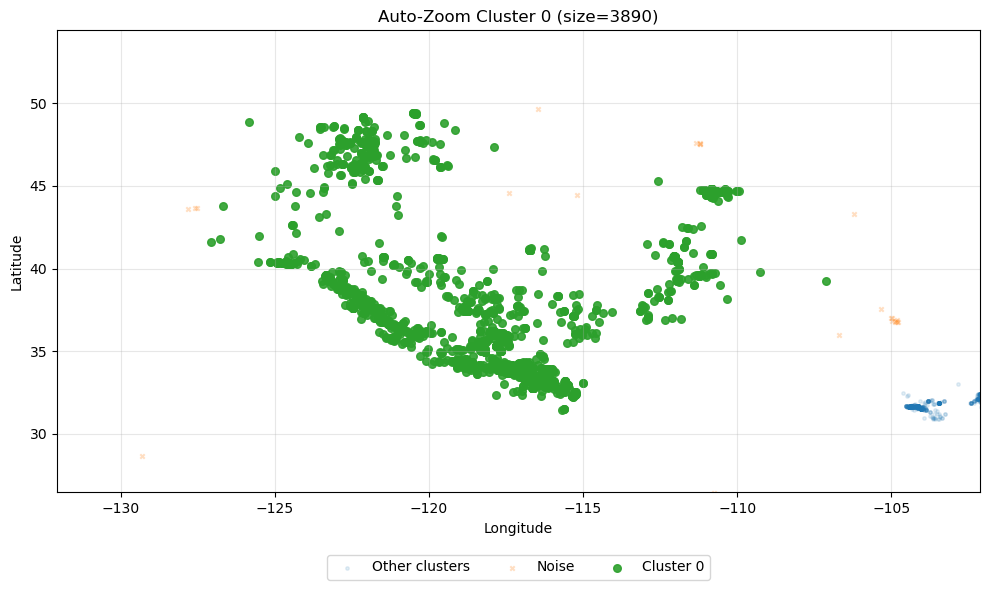

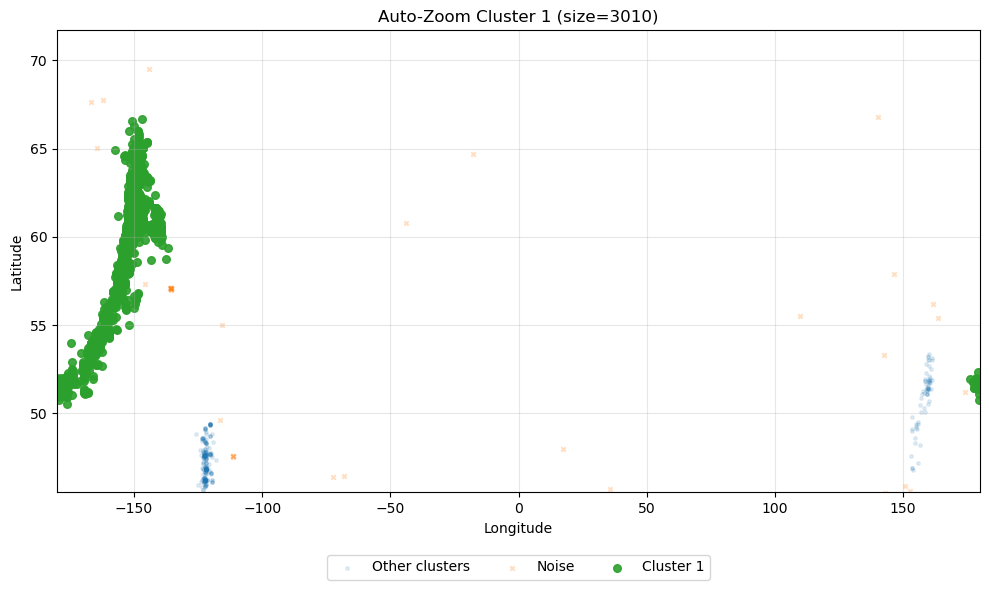

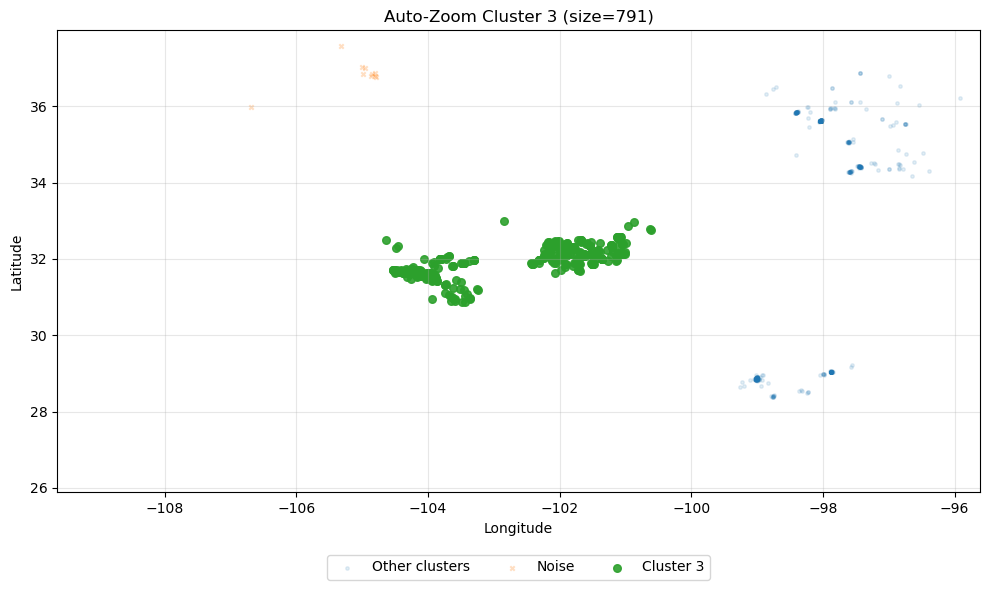

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def auto_bounds(lon: np.ndarray, lat: np.ndarray, margin_deg: float = 5.0):
    xmin, xmax = float(np.min(lon)), float(np.max(lon))
    ymin, ymax = float(np.min(lat)), float(np.max(lat))

    xmin -= margin_deg; xmax += margin_deg
    ymin -= margin_deg; ymax += margin_deg

    # clamp to valid world bounds
    xmin = max(-180, xmin); xmax = min(180, xmax)
    ymin = max(-90, ymin);  ymax = min(90, ymax)
    return xmin, xmax, ymin, ymax


def show_top_clusters(df: pd.DataFrame, top_n: int = 10):
    """
    Returns a Series: cluster_id -> count (excluding noise=-1)
    """
    vc = df.loc[df["cluster"] != -1, "cluster"].value_counts().head(top_n)
    print("\n--- Top Clusters (by size) ---")
    print(vc)
    return vc


def plot_highlight_cluster_zoom(df: pd.DataFrame, cluster_id: int, margin_deg: float = 5.0):
    """
    Zoom plot showing:
    - selected cluster (highlight)
    - other clusters (faint)
    - noise (x)
    """
    selected = df[df["cluster"] == cluster_id]
    if selected.empty:
        print(f"Cluster {cluster_id} not found.")
        return

    others = df[(df["cluster"] != cluster_id) & (df["cluster"] != -1)]
    noise  = df[df["cluster"] == -1]

    xmin, xmax, ymin, ymax = auto_bounds(
        selected["longitude"].to_numpy(),
        selected["latitude"].to_numpy(),
        margin_deg=margin_deg
    )

    plt.figure(figsize=(10, 6))

    if not others.empty:
        plt.scatter(others["longitude"], others["latitude"],
                    s=6, alpha=0.12, label="Other clusters")

    if not noise.empty:
        plt.scatter(noise["longitude"], noise["latitude"],
                    s=10, marker="x", alpha=0.25, label="Noise")

    plt.scatter(selected["longitude"], selected["latitude"],
                s=30, alpha=0.9, label=f"Cluster {cluster_id}")

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(f"Auto-Zoom Cluster {cluster_id} (size={len(selected)})")
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.grid(True, alpha=0.3)

    plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=True)
    plt.tight_layout()
    plt.show()


def plot_top_clusters_zoom(df: pd.DataFrame, top_k: int = 3, margin_deg: float = 5.0):
    """
    Plots zoomed maps for the top_k largest clusters (excluding noise).
    """
    top_series = show_top_clusters(df, top_n=top_k)
    for cid in top_series.index:
        plot_highlight_cluster_zoom(df, int(cid), margin_deg=margin_deg)
plot_top_clusters_zoom(df_plot, top_k=3, margin_deg=5.0)

In [27]:
def run_dbscan_once(coords_rad, eps_km, min_samples):
    labels, core_idx, _ = run_dbscan_haversine(coords_rad, eps_km=float(eps_km), min_samples=int(min_samples))
    return labels, core_idx

def clustering_metrics(coords_rad, labels):
    n = len(labels)
    noise = int((labels == -1).sum())
    clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (noise / n) * 100 if n else 0

    mask = labels != -1
    coords_nn = coords_rad[mask]
    labels_nn = labels[mask]

    sil = None
    dbi = None
    if len(set(labels_nn.tolist())) >= 2:
        sil = float(silhouette_score(coords_nn, labels_nn, metric="euclidean"))
        dbi = float(davies_bouldin_score(coords_nn, labels_nn))

    return clusters, noise_pct, sil, dbi

def parameter_sweep(coords_rad,
                    eps_list=(20, 30, 40, 50, 60, 80, 100, 120, 150),
                    min_samples_list=(6, 10, 15)):
    rows = []
    for ms in min_samples_list:
        for eps in eps_list:
            labels, _ = run_dbscan_once(coords_rad, eps_km=eps, min_samples=ms)
            clusters, noise_pct, sil, dbi = clustering_metrics(coords_rad, labels)
            rows.append({
                "eps_km": float(eps),
                "min_samples": int(ms),
                "clusters": int(clusters),
                "noise_pct": float(noise_pct),
                "silhouette": sil,
                "davies_bouldin": dbi
            })
    return pd.DataFrame(rows)

results_df = parameter_sweep(coords_rad)
results_df


,eps_km,min_samples,clusters,noise_pct,silhouette,davies_bouldin
0,20.0,6,112,17.599586,0.304170,0.380493
1,30.0,6,76,13.150543,0.483770,0.336099
2,40.0,6,65,10.729436,0.503957,0.568451
3,50.0,6,55,8.825660,0.413855,2.631482
4,60.0,6,46,7.697879,0.128607,2.557798
5,80.0,6,40,6.301086,0.265405,2.933414
6,100.0,6,36,5.649250,0.213011,2.875271
7,120.0,6,36,5.038800,0.208342,1.465585
8,150.0,6,35,4.428350,0.297800,1.518379
9,20.0,10,71,23.424728,0.581999,0.350097


In [28]:
def choose_best(results: pd.DataFrame, max_noise_pct: float = 60.0):
    df = results.copy()
    df = df[df["silhouette"].notna()].copy()
    df = df[df["noise_pct"] <= max_noise_pct].copy()

    df["score"] = (
        df["silhouette"] * 1.0
        - (df["noise_pct"] / 100.0) * 0.4
        - (df["davies_bouldin"].fillna(df["davies_bouldin"].max()) / 10.0) * 0.2
    )

    df = df.sort_values("score", ascending=False).reset_index(drop=True)
    return df

ranked_df = choose_best(results_df, max_noise_pct=60.0)
ranked_df.head(10)


,eps_km,min_samples,clusters,noise_pct,silhouette,davies_bouldin,score
0,40.0,15,36,16.420072,0.659821,0.277532,0.588590
1,150.0,15,17,6.952923,0.616975,0.277222,0.583619
2,60.0,15,32,11.929643,0.635976,0.403606,0.580185
3,20.0,15,59,27.315054,0.694320,0.345194,0.578156
4,50.0,15,35,14.102431,0.635662,0.275374,0.573745
5,30.0,15,47,20.289705,0.637306,0.325859,0.549630
6,40.0,10,52,13.512675,0.598406,0.315063,0.538054
7,50.0,10,51,10.594930,0.576566,0.782585,0.518535
8,30.0,10,56,16.823590,0.568580,0.298457,0.495316
9,20.0,10,71,23.424728,0.581999,0.350097,0.481298


In [29]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score, davies_bouldin_score

def clustering_metrics(coords_rad, labels):
    labels = np.asarray(labels)
    n = len(labels)

    noise = int((labels == -1).sum())
    clusters = len(set(labels)) - (1 if -1 in set(labels) else 0)
    noise_pct = (noise / n) * 100 if n else 0

    mask = labels != -1
    X = coords_rad[mask]
    y = labels[mask]

    sil = None
    dbi = None

    # silhouette requires at least 2 clusters
    if len(y) > 1 and len(set(y)) >= 2:
        sil = float(silhouette_score(X, y, metric="haversine"))  
        dbi = float(davies_bouldin_score(X, y))                  

    return clusters, noise_pct, sil, dbi

In [30]:
def parameter_sweep(coords_rad, eps_list, min_samples_list):
    rows = []
    for ms in min_samples_list:
        for eps in eps_list:
            labels, core_idx, _ = run_dbscan_haversine(coords_rad, eps_km=float(eps), min_samples=int(ms))
            clusters, noise_pct, sil, dbi = clustering_metrics(coords_rad, labels)
            rows.append({
                "eps_km": float(eps),
                "min_samples": int(ms),
                "clusters": int(clusters),
                "noise_pct": float(noise_pct),
                "silhouette": sil,
                "davies_bouldin": dbi
            })
    return pd.DataFrame(rows)

eps_list = [80, 100, 120, 140, 160, 168.33, 180, 200]
min_samples_list = [5, 8, 10, 12, 15]

sweep_df = parameter_sweep(coords_rad, eps_list, min_samples_list)
sweep_df.head()

,eps_km,min_samples,clusters,noise_pct,silhouette,davies_bouldin
0,80.0,5,43,6.001035,0.318410,2.938671
1,100.0,5,41,5.225039,0.353481,2.652906
2,120.0,5,38,4.718055,0.311108,1.484174
3,140.0,5,39,4.314537,0.258756,1.474619
4,160.0,5,38,3.745473,0.499798,1.352112


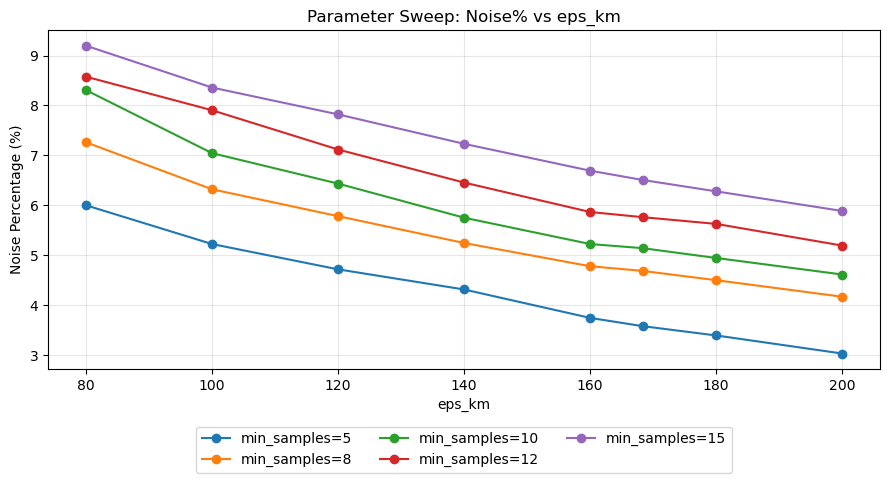

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))
for ms in min_samples_list:
    subset = sweep_df[sweep_df["min_samples"] == ms].sort_values("eps_km")
    plt.plot(subset["eps_km"], subset["noise_pct"], marker="o", label=f"min_samples={ms}")

plt.title("Parameter Sweep: Noise% vs eps_km")
plt.xlabel("eps_km")
plt.ylabel("Noise Percentage (%)")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True)
plt.tight_layout()
plt.show()

In [32]:
print("df_geo:", "df_geo" in globals())
print("df_types:", "df_types" in globals())
print("df_dedup:", "df_dedup" in globals())

df_geo: True
df_types: True
df_dedup: True


In [33]:
df_clean = df_geo.copy()   # best choice (final cleaned + ready for clustering)
print("df_clean rows, cols:", df_clean.shape)

df_clean rows, cols: (9665, 8)


In [34]:
import numpy as np

coords_rad = np.radians(df_clean[["latitude", "longitude"]].to_numpy())
print("coords_rad shape:", coords_rad.shape)

coords_rad shape: (9665, 2)


In [35]:
import numpy as np

def dbscan_summary(labels):
    labels = np.asarray(labels)
    n = len(labels)
    noise = int((labels == -1).sum())
    clusters = len(set(labels)) - (1 if -1 in set(labels) else 0)
    noise_pct = (noise / n) * 100 if n else 0.0

    return {
        "total_points": int(n),
        "clusters": int(clusters),
        "noise_points": int(noise),
        "noise_pct": float(noise_pct),
    }

In [36]:
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score

def dbscan_metrics(coords_rad, labels):
    """
    coords_rad: numpy array shape (n,2) in radians [lat_rad, lon_rad]
    labels: DBSCAN labels (-1 is noise)
    Returns internal metrics computed on non-noise points only.
    """
    labels = np.asarray(labels)
    n = len(labels)

    noise = int((labels == -1).sum())
    clusters = len(set(labels)) - (1 if -1 in set(labels) else 0)
    noise_pct = (noise / n) * 100 if n else 0.0

    # compute metrics on non-noise points only
    mask = labels != -1
    coords_nn = np.asarray(coords_rad)[mask]
    labels_nn = labels[mask]

    sil = None
    dbi = None

    # need at least 2 clusters (non-noise) to compute silhouette/DBI
    if len(coords_nn) > 1 and len(np.unique(labels_nn)) >= 2:
        sil = float(silhouette_score(coords_nn, labels_nn, metric="euclidean"))
        dbi = float(davies_bouldin_score(coords_nn, labels_nn))

    return {
        "clusters": int(clusters),
        "noise_pct": float(noise_pct),
        "silhouette": sil,
        "davies_bouldin": dbi,
    }

In [37]:
def plot_world(df, title="DBSCAN World Plot"):
    """
    Wrapper so your CLI can call plot_world().
    Uses plot_core_border_noise() if it exists.
    """
    if "plot_core_border_noise" in globals():
        # If core_idx exists from last DBSCAN run, use it
        if "core_idx" in globals():
            plot_core_border_noise(df, core_idx, title=title)
        else:
            # fallback: just call without core_idx if you don't have it
            print("core_idx not found. Run DBSCAN first to generate core_idx.")
    else:
        raise NameError("plot_core_border_noise() not found. Define your plotting function first.")

In [38]:
import pandas as pd

def print_top_clusters(df: pd.DataFrame, top_n: int = 10) -> None:
    vc = df[df["cluster"] != -1]["cluster"].value_counts().head(top_n)
    if vc.empty:
        print("No clusters found.")
        return
    print("\nTop clusters by size:")
    for cid, size in vc.items():
        print(f"  Cluster {cid}: {size} events")

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def _auto_bounds(lon: np.ndarray, lat: np.ndarray, margin_deg: float = 5.0):
    xmin, xmax = float(lon.min()), float(lon.max())
    ymin, ymax = float(lat.min()), float(lat.max())
    xmin -= margin_deg; xmax += margin_deg
    ymin -= margin_deg; ymax += margin_deg
    xmin = max(-180, xmin); xmax = min(180, xmax)
    ymin = max(-90, ymin);  ymax = min(90, ymax)
    return xmin, xmax, ymin, ymax

def plot_highlight_cluster(df: pd.DataFrame, cluster_id: int, margin_deg: float = 5.0):
    if "cluster" not in df.columns:
        print("No 'cluster' column found. Run DBSCAN first.")
        return

    selected = df[df["cluster"] == cluster_id]
    if selected.empty:
        print("Cluster not found.")
        return

    others = df[(df["cluster"] != cluster_id) & (df["cluster"] != -1)]
    noise  = df[df["cluster"] == -1]

    xmin, xmax, ymin, ymax = _auto_bounds(
        selected["longitude"].to_numpy(),
        selected["latitude"].to_numpy(),
        margin_deg=margin_deg
    )

    plt.figure(figsize=(10, 6))
    if not others.empty:
        plt.scatter(others["longitude"], others["latitude"], s=6, alpha=0.12, label="Other clusters")
    if not noise.empty:
        plt.scatter(noise["longitude"], noise["latitude"], s=10, marker="x", alpha=0.25, label="Noise")

    plt.scatter(selected["longitude"], selected["latitude"], s=30, alpha=0.9, label=f"Cluster {cluster_id}")

    plt.title(f"Auto-Zoom Cluster {cluster_id} (size={len(selected)})")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=True)
    plt.tight_layout()
    plt.show()

In [40]:
import pandas as pd

def inspect_cluster(df: pd.DataFrame, cluster_id: int) -> None:
    if "cluster" not in df.columns:
        print("No 'cluster' column found. Run DBSCAN first.")
        return

    sub = df[df["cluster"] == cluster_id].copy()
    if sub.empty:
        print("Cluster not found.")
        return

    # Basic stats
    avg_mag = sub["mag"].mean() if "mag" in sub.columns else None
    avg_depth = sub["depth"].mean() if "depth" in sub.columns else None

    print(f"\nCluster {cluster_id} size: {len(sub)}")

    if avg_mag is not None and pd.notna(avg_mag):
        print(f"Average magnitude: {avg_mag:.2f}")
    else:
        print("Average magnitude: N/A")

    if avg_depth is not None and pd.notna(avg_depth):
        print(f"Average depth (km): {avg_depth:.2f}")
    else:
        print("Average depth (km): N/A")

    # Show a few example places
    if "place" in sub.columns:
        print("\nExample places:")
        for p in sub["place"].dropna().head(8).tolist():
            print(f"  - {p}")

    # Preview rows
    display(sub[["id","time","latitude","longitude","depth","mag","place","cluster"]].head(10))

In [41]:
def run_cli():
    global df_clean, coords_rad, eps_km, min_samples

    # --- Pre-run checks (prevents NameError) ---
    if "df_clean" not in globals():
        raise NameError("df_clean is not defined. Create it first (e.g., df_clean = df_geo.copy()).")

    if "coords_rad" not in globals():
        raise NameError("coords_rad is not defined. Create it first (np.radians on lat/lon).")

    if "run_dbscan_haversine" not in globals():
        raise NameError("run_dbscan_haversine is not defined. Run the cell that defines it first.")

    # store last run results (so option 4 can work)
    last_labels = None

    while True:
        print("\n=== DBSCAN CLI (Jupyter) ===")
        print("1) Run DBSCAN")
        print("2) Show top clusters + highlight one on plot")
        print("3) Inspect a cluster + highlight on plot")
        print("4) Show full plot")
        print("5) Export clustered CSV")
        print("0) Exit")

        choice = input("Select: ").strip()

        if choice == "0":
            print("Exit.")
            break

        elif choice == "1":
            eps_km = float(input("eps_km (50/80/120): ").strip())
            min_samples = int(input("min_samples (6/10/15): ").strip())

            # ✅ handle both return styles:
            # - labels only
            # - (labels, core_idx, model)
            res = run_dbscan_haversine(coords_rad, eps_km=eps_km, min_samples=min_samples)
            if isinstance(res, (tuple, list)):
                labels = res[0]
            else:
                labels = res

            df_clean["cluster"] = labels
            last_labels = labels

            # these must already exist in your notebook (as you used before)
            print("Summary:", dbscan_summary(labels))
            print("Metrics:", dbscan_metrics(coords_rad, labels))

            plot_world(df_clean, title=f"DBSCAN (eps={eps_km}km, min_samples={min_samples})")

        elif choice == "2":
            if "cluster" not in df_clean.columns:
                print("Run DBSCAN first (option 1).")
                continue
            print_top_clusters(df_clean, top_n=10)
            cid = input("Enter cluster id to highlight: ").strip()
            if cid:
                plot_highlight_cluster(df_clean, int(cid))

        elif choice == "3":
            if "cluster" not in df_clean.columns:
                print("Run DBSCAN first (option 1).")
                continue
            cid = int(input("Cluster id: ").strip())
            inspect_cluster(df_clean, cid)
            plot_highlight_cluster(df_clean, cid)

        elif choice == "4":
            if "cluster" not in df_clean.columns:
                print("Run DBSCAN first (option 1).")
            else:
                plot_world(df_clean, title="DBSCAN Full Plot")

        elif choice == "5":
            if "cluster" not in df_clean.columns:
                print("Run DBSCAN first (option 1).")
            else:
                out = "earthquakes_clustered.csv"
                df_clean.to_csv(out, index=False)
                print(f"Exported: {out}")

        else:
            print("Invalid option.")


=== DBSCAN CLI (Jupyter) ===
1) Run DBSCAN
2) Show top clusters + highlight one on plot
3) Inspect a cluster + highlight on plot
4) Show full plot
5) Export clustered CSV
0) Exit


Select:  1
eps_km (50/80/120):  50
min_samples (6/10/15):  10


Summary: {'total_points': 9665, 'clusters': 51, 'noise_points': 1024, 'noise_pct': 10.594930160372478}
Metrics: {'clusters': 51, 'noise_pct': 10.594930160372478, 'silhouette': 0.5765662312018701, 'davies_bouldin': 0.7825848723557758}


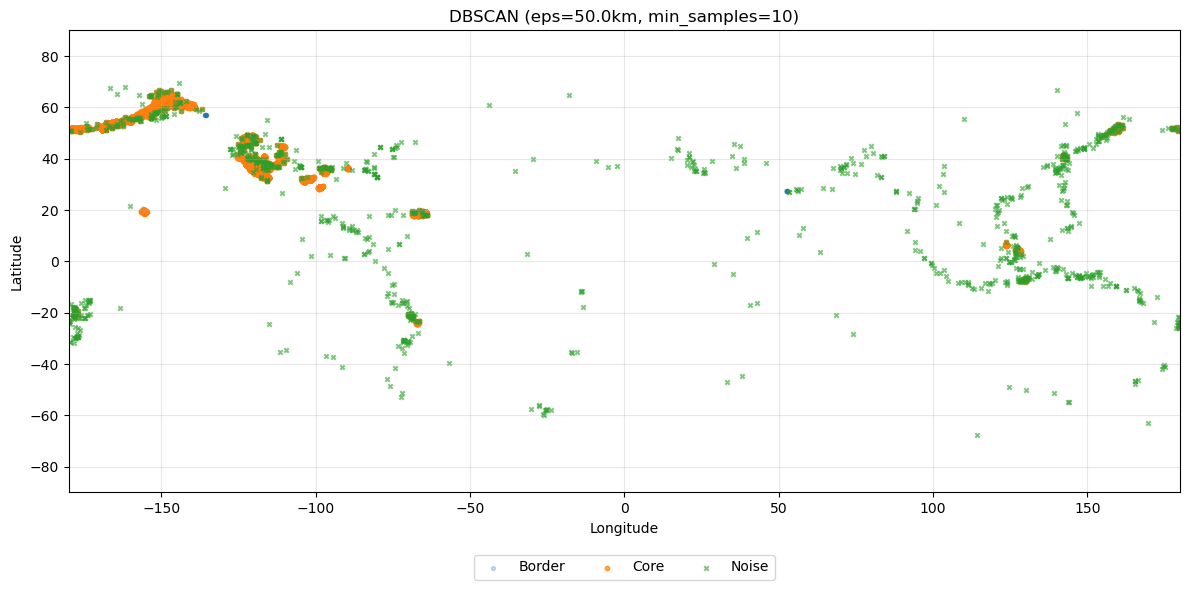


=== DBSCAN CLI (Jupyter) ===
1) Run DBSCAN
2) Show top clusters + highlight one on plot
3) Inspect a cluster + highlight on plot
4) Show full plot
5) Export clustered CSV
0) Exit


In [ ]:
run_cli()